# LangSmith 로 그래프 디버깅

- LangGraph 는 노드별로 실행되니까 트레이스 트리가 훨씬 직관적입니다. **"어디서 답이 이상해진 거지?" 를 클릭 한 번에** 찾을 수 있게 됩니다.

## 환경 셋업


```
OPENAI_API_KEY=sk-...
LANGSMITH_API_KEY=lsv2_pt_...
LANGSMITH_TRACING=true
LANGSMITH_PROJECT=mtvs2026-langgraph
```

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

print("OPENAI_API_KEY:", "있음" if os.getenv("OPENAI_API_KEY") else "없음")
print("LANGSMITH_TRACING:", os.getenv("LANGSMITH_TRACING"))

OPENAI_API_KEY: 있음
LANGSMITH_TRACING: true


### LangSmith 계정·API 키가 아직 없으면

이 노트북의 1~2번 절 (그래프 호출 + 트레이스 자동 기록) 은 키 없이도 그래프 자체는 잘 동작합니다. 다만 LangSmith UI 에 결과가 안 쌓일 뿐. 3~4번 절 (Dataset 생성 / evaluate) 은 키가 필요하니 일단 **셀을 건너뛰고** 1~2번만 진행해도 됩니다.

`.env` 에 다음 두 줄이 있어야 트래이싱이 켜진 상태입니다.

```
LANGSMITH_API_KEY=lsv2_pt_...
LANGSMITH_TRACING=true
```

가입은 <https://smith.langchain.com/> 

## 1. 다중 노드 그래프, 트레이스로 단계 확인

- `LANGSMITH_TRACING=true` 만 켜져 있으면 LangGraph 그래프의 매 노드 호출이 자동으로 트레이스 트리에 기록.

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage

llm = init_chat_model("openai:gpt-5.4-mini")


def stage_summary(state: MessagesState) -> dict:
    """1단계: 고객 문의를 한 문장으로 요약."""
    msgs = state["messages"] + [HumanMessage("이 고객 문의를 한 문장으로 요약해줘.")]
    return {"messages": [llm.invoke(msgs)]}


def stage_classify(state: MessagesState) -> dict:
    """2단계: 요약을 보고 티켓 유형 분류."""
    msgs = state["messages"] + [HumanMessage("위 내용을 배송/환불/교환/계정 중 하나의 티켓 유형으로 분류하고 이유를 한 줄로 써줘.")]
    return {"messages": [llm.invoke(msgs)]}


def stage_reply(state: MessagesState) -> dict:
    """3단계: 고객에게 보낼 답변 초안 작성."""
    msgs = state["messages"] + [HumanMessage("이 티켓에 대해 고객에게 보낼 답변 초안을 정중하게 한 문단으로 작성해줘.")]
    return {"messages": [llm.invoke(msgs)]}



In [3]:
graph = StateGraph(MessagesState)
graph.add_node('summary', stage_summary)
graph.add_node('classify', stage_classify)
graph.add_node('reply', stage_reply)
graph.add_edge(START, 'summary')
graph.add_edge('summary', 'classify')
graph.add_edge('classify', 'reply')
graph.add_edge('reply', END)
app = graph.compile()

In [4]:
result = app.invoke({'messages':[HumanMessage('주문 O=1001이 5일째 배송되지 않았고 고객이 환불 가능 여부를 문의했습니다.')]})
print("최종 고객 답변:", result["messages"][-1].content)
print()
print(f"LangSmith 에서 'summary -> classify -> reply' 트리 확인:")
print(f"  https://smith.langchain.com/projects/{os.getenv('LANGSMITH_PROJECT')}")


최종 고객 답변: 안녕하세요, 고객님. 주문 O=1001의 배송이 5일째 지연되어 불편을 드린 점 진심으로 사과드립니다. 현재 배송 상태를 확인해보는 중이며, 상황에 따라 환불 가능 여부도 함께 안내드릴 수 있도록 하겠습니다. 번거로우시겠지만 조금만 기다려 주시면 최대한 신속하게 확인하여 다시 연락드리겠습니다. 감사합니다.

LangSmith 에서 'summary -> classify -> reply' 트리 확인:
  https://smith.langchain.com/projects/agent_langgraph


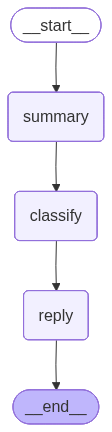

In [6]:
app

## 2. 메타데이터·태그로 분류

- 같은 프로젝트 안에서도 환경·실험 ID 로 트레이스 분류.

In [9]:
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(
    tags=['day2', 'support-ticket-graph'],
    metadata={'scenario': "delayed_delivery", "version":"v0.1"}
)

result = app.invoke(
    {"messages":[HumanMessage("고객이 반품 신청 후 환불이 아직 안 들어왔다고 문의했습니다.")]},
    config=config
)
result['messages'][-1].content

'안녕하세요, 고객님. 반품 신청 후 환불이 아직 처리되지 않아 불편을 드려 죄송합니다. 현재 환불 진행 상태를 확인 중이며, 반품 상품 수거 및 검수 완료 여부에 따라 환불이 순차적으로 진행될 수 있습니다. 확인되는 대로 신속히 안내드리겠습니다. 감사합니다.'

## 3. 트레이스 UI 에서 보이는 것

1. **각 노드의 입력·출력** (펼쳐서 확인)
2. **노드별 latency / token usage / cost**
3. **에러 발생 노드** 빨간색 강조
4. **부모-자식 트리** (`stage_summary → llm.invoke` 안의 OpenAI 호출까지)


## 4. 정리

- LangGraph 그래프는 LangSmith 에 **노드별로 자동 분기되어** 기록됨
- `tags` / `metadata` 로 실험·버전 구분
- `evaluate()` 로 평가셋 자동 실행 → UI 에서 결과 비교
- 다음 노트북 (06 폴더) 에서 ReAct + 평가셋 더 본격적으로


### [실습]


1. 같은 그래프를 3 번 호출하고 LangSmith UI 에서 평균 latency 확인.
2. `tags=["test"]` 로 한 번, `tags=["prod"]` 로 한 번 호출 후 UI 에서 필터링.
3. `stage_classify` 노드 안에서 일부러 예외 발생 → LangSmith 트레이스에서 빨간 노드 확인.
4. Dataset 에 예제 5개 더 추가해 `evaluate()` 한 번 실행.
5. 두 가지 system 프롬프트 버전 (v1 vs v2) 의 그래프를 같은 데이터셋에 돌려 LangSmith UI 의 "Compare experiments" 로 비교.


In [10]:
config = RunnableConfig(
    tags=['test', 'prod'],
    metadata={'scenario': "delayed_delivery", "version":"v0.1"}
)

result = app.invoke(
    {"messages":[HumanMessage("고객이 반품 신청 후 환불이 아직 안 들어왔다고 문의했습니다.")]},
    config=config
)
result['messages'][-1].content

'안녕하세요, 고객님. 반품 신청 후 환불이 아직 완료되지 않아 불편을 드려 죄송합니다. 현재 환불 진행 상태를 확인 중이며, 결제 수단 및 반품 처리 완료 시점에 따라 환불 반영까지 시간이 다소 소요될 수 있습니다. 확인되는 대로 신속히 안내드리겠습니다. 조금만 기다려 주시면 감사하겠습니다.'